In [1]:
import numpy as np
import sys

Base_Dir = './' # assuming we are in zeldovich-smearing/examples/, else modify this
Like_Dir = Base_Dir + '../code/'
sys.path.append(Like_Dir)

from inference import StrongSampler

from paths import *
sys.path.append(ML_Path)
from mllib import Utilities

import gc
from time import time

ut = Utilities()

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 16 # 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# BAO Multipole Models
### Analysis of Zel'dovich smearing model with strong prior
***

## Setup

In [3]:
Sample = 'DESI-LRG2'
Cosmo = 'nucdm'
Flat = False

Include_Emulator_Error = True

Model_AP = True
Include_Sig2Obs = True
L_Max = 3

setup = {'base_dir':Base_Dir,
         'sample':Sample,
         'model_AP':Model_AP,
         'include_Sig2obs':Include_Sig2Obs,
         'L_Max':L_Max,
         'cosmo':Cosmo,'flat':Flat,
         'include_emulator_error':Include_Emulator_Error}

ssamp = StrongSampler(setup=setup)

Plots dir: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/
Scales file: ./data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800_scales.txt
Cov mat file: ./data/AbacusSummit/base_c000/DESI-LRG2/covmat_LMax3_lgMmin12.90_z0.800_inclSig2obs_AP.txt
xi_lin file: ./data/AbacusSummit/base_c000/DESI-LRG2/xilin.txt
Data files: [./data/AbacusSummit/base_c000/DESI-LRG2/Sig2obs_LMax3_lgMmin12.90_z0.800.txt,./data/AbacusSummit/base_c000/DESI-LRG2/xi_LMax3_lgMmin12.90_z0.800.txt]
id string stem: AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/mcmc_LMax3_lgMmin12.90_z0.800_inclSig2obs
Agnostic emulator for BAO inference...
... will work in folder: ./../code/../emulation/emulators/scale6.0/z0.80/
... extracting basis functions as NN
... done
... evaluating 9 basis functions
... done
... setting up fiducial cosmology and sampling ranges
... setting up parameter variations for family: nucdm
... fiducial params:
... ... Om: 3.1530e-01
... ...

## Ground truth
#### Dictionary of ground truth values for cosmological and derived parameters

In [4]:
GT_Dict = {'Om':0.3138,'Ob':0.0493,'h':0.6736,'ns':0.9649,'As':np.exp(3.0364)*1e-10,
           'Ok':0.0,'wDE0':-1.0,'wDEa':0.0,'m_ncdm':0.06}
GT_Dict['f'] = {'':0.81735,'DESI-LRG2':0.83891,'Euclid-ELG':0.88902}
GT_Dict['LP'] = {'':93.1636,'DESI-LRG2':93.0358,'Euclid-ELG':93.0358}
GT_Dict['ZC'] = {'':120.5840,'DESI-LRG2':120.6466,'Euclid-ELG':120.6466}

## Priors
#### Modify priors for poorly constrained cosmological parameters

In [5]:
# comment/uncomment and modify as needed

# # n_s
# ssamp.info['params']['ns']['prior'] = {'dist':'norm','loc':ssamp.agem.pfid['ns'],'scale':0.0042}

# # Omega_b
# sig_Ob = ssamp.agem.pfid['Ob']*np.sqrt((6.7054e-3)**2 + 4*(8.0166e-3)**2)
# ssamp.info['params']['Ob']['prior'] = {'dist':'norm','loc':ssamp.agem.pfid['Ob'],'scale':sig_Ob} 

# # A_s
# ssamp.info['params']['As']['prior'] = {'dist':'norm','loc':ssamp.agem.pfid['As'],'scale':0.015*ssamp.agem.pfid['As']}


In [6]:
print('Output:',ssamp.info['output'])
print('Priors:')
for key in ssamp.info['params'].keys():
    if not np.isscalar(ssamp.info['params'][key]):
        if 'prior' in ssamp.info['params'][key].keys():
            print(key,ssamp.info['params'][key]['prior'])

Output: stats/chains/varymc/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/mcmc_LMax3_lgMmin12.90_z0.800_inclSig2obs
Priors:
Om {'min': 0.2715, 'max': 0.35910000000000003}
h {'min': 0.6413, 'max': 0.7061}
As {'min': np.float64(1.924518858183763e-09), 'max': np.float64(2.277487382392139e-09)}
ns {'min': 0.9397, 'max': 0.9901}
Ob {'min': np.float64(0.04414836408043076), 'max': np.float64(0.05442575055535983)}
Ok {'min': -0.07500000000000001, 'max': 0.07500000000000001}
m_ncdm {'min': 0.0009557522123893805, 'max': 0.3}
b {'dist': 'norm', 'loc': 2.383, 'scale': 0.11915}
B1st {'min': -100.0, 'max': 100.0}
Bvst {'min': -100.0, 'max': 100.0}
sigma {'min': 0.0, 'max': 12.0}
AMC {'dist': 'norm', 'loc': 0.0, 'scale': 0.05}
qbar2 {'min': -2.0, 'max': 2.0}


## Run chains

In [7]:
Force = True   # set to False if chains exist and only need to be loaded
Resume = False # set to True if chains exist and need to be resumed

gd_sample = ssamp.run_mcmc(force=Force,resume=Resume)

[output] Output to be read-from/written-into folder 'stats/chains/varymc/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr', with prefix 'mcmc_LMax3_lgMmin12.90_z0.800_inclSig2obs'
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
Extracting basis functions as NN...
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with ca

/home/aseem/iucaa/ModelSelection/BAO2pcf/zeldovich-smearing/code/zelsmear.py:218: RuntimeWarning: divide by zero encountered in log
  logp_eval = np.log(np.mean(np.exp(logp_n)))


[mcmc] Learn + convergence test @ 35880 samples accepted.
[mcmc]  - Acceptance rate: 0.226
[mcmc]  - Convergence of means: R-1 = 0.025530 after 28704 accepted steps
[blockedproposer] *ERROR* The given covmat is not a positive-definite, symmetric square matrix.
[mcmc] Learn + convergence test @ 36400 samples accepted.
[mcmc]  - Acceptance rate: 0.225
[mcmc]  - Convergence of means: R-1 = 0.031336 after 29120 accepted steps
[blockedproposer] *ERROR* The given covmat is not a positive-definite, symmetric square matrix.
[mcmc] Learn + convergence test @ 36920 samples accepted.
[mcmc]  - Acceptance rate: 0.224
[mcmc]  - Convergence of means: R-1 = 0.031839 after 29536 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 37440 samples accepted.
[mcmc]  - Acceptance rate: 0.224
[mcmc]  - Convergence of means: R-1 = 0.030459 after 29952 accepted steps
[blockedproposer] *ERROR* The given covmat is not a positive-definite, symmetric square matrix.

/home/aseem/iucaa/ModelSelection/BAO2pcf/zeldovich-smearing/code/zelsmear.py:218: RuntimeWarning: divide by zero encountered in log
  logp_eval = np.log(np.mean(np.exp(logp_n)))


[mcmc] Progress @ 2026-07-31 18:23:20 : 722692 steps taken, and 151110 accepted.
[mcmc] Learn + convergence test @ 151320 samples accepted.
[mcmc]  - Acceptance rate: 0.198
[mcmc]  - Convergence of means: R-1 = 0.007544 after 121056 accepted steps
[mcmc]  - Convergence of bounds: R-1 = 0.061999 after 151320 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 151840 samples accepted.
[mcmc]  - Acceptance rate: 0.198
[mcmc]  - Convergence of means: R-1 = 0.008473 after 121472 accepted steps
[mcmc]  - Convergence of bounds: R-1 = 0.065925 after 151840 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test @ 152360 samples accepted.
[mcmc]  - Acceptance rate: 0.198
[mcmc]  - Convergence of means: R-1 = 0.008212 after 121888 accepted steps
[mcmc]  - Convergence of bounds: R-1 = 0.068345 after 152360 accepted steps
[mcmc]  - Updated covariance matrix of proposal pdf.
[mcmc] Learn + convergence test

In [8]:
mcmc_MAP,mcmc_best,chi2_min,pval,par_show = ssamp.display_stats(gd_sample)

... MAP       = ( 3.283e-01,6.499e-01,1.978e-09,9.868e-01,5.061e-02,-5.945e-02,1.532e-02,2.366e+00,-2.308e+00,8.113e+00,8.349e+00,1.955e-02,1.382e-02,8.768e-01,1.014e+02,9.404e+01,1.217e+02,7.432e-03,-1.430e-02,-9.227e-03,1.660e-02,6.039e-03,1.643e-02,-1.786e-02,4.782e-03,1.856e-02 )
... best fit  = ( 3.116e-01,6.635e-01,2.222e-09,9.841e-01,4.993e-02,-1.121e-03,5.001e-02,2.326e+00,-2.239e+00,7.861e+00,8.393e+00,1.485e-02,3.605e-02,8.404e-01,1.012e+02,9.400e+01,1.224e+02,6.996e-03,-1.424e-02,-9.045e-03,1.579e-02,4.880e-03,1.655e-02,-1.726e-02,4.452e-03,1.811e-02 )
... std dev   = ( 1.824e-02,1.586e-02,9.777e-11,1.388e-02,2.332e-03,3.824e-02,8.067e-02,8.753e-02,6.225e-01,2.525e+00,9.345e-01,1.695e-02,5.844e-02 )
... chi2_best,dof,chi2_red,pval: 56.096,78,0.719,9.718e-01


## Plot

In [9]:
Save_Fig = True

### Contour plots

#### Full distribution

Writing to file: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/contours_all.pdf


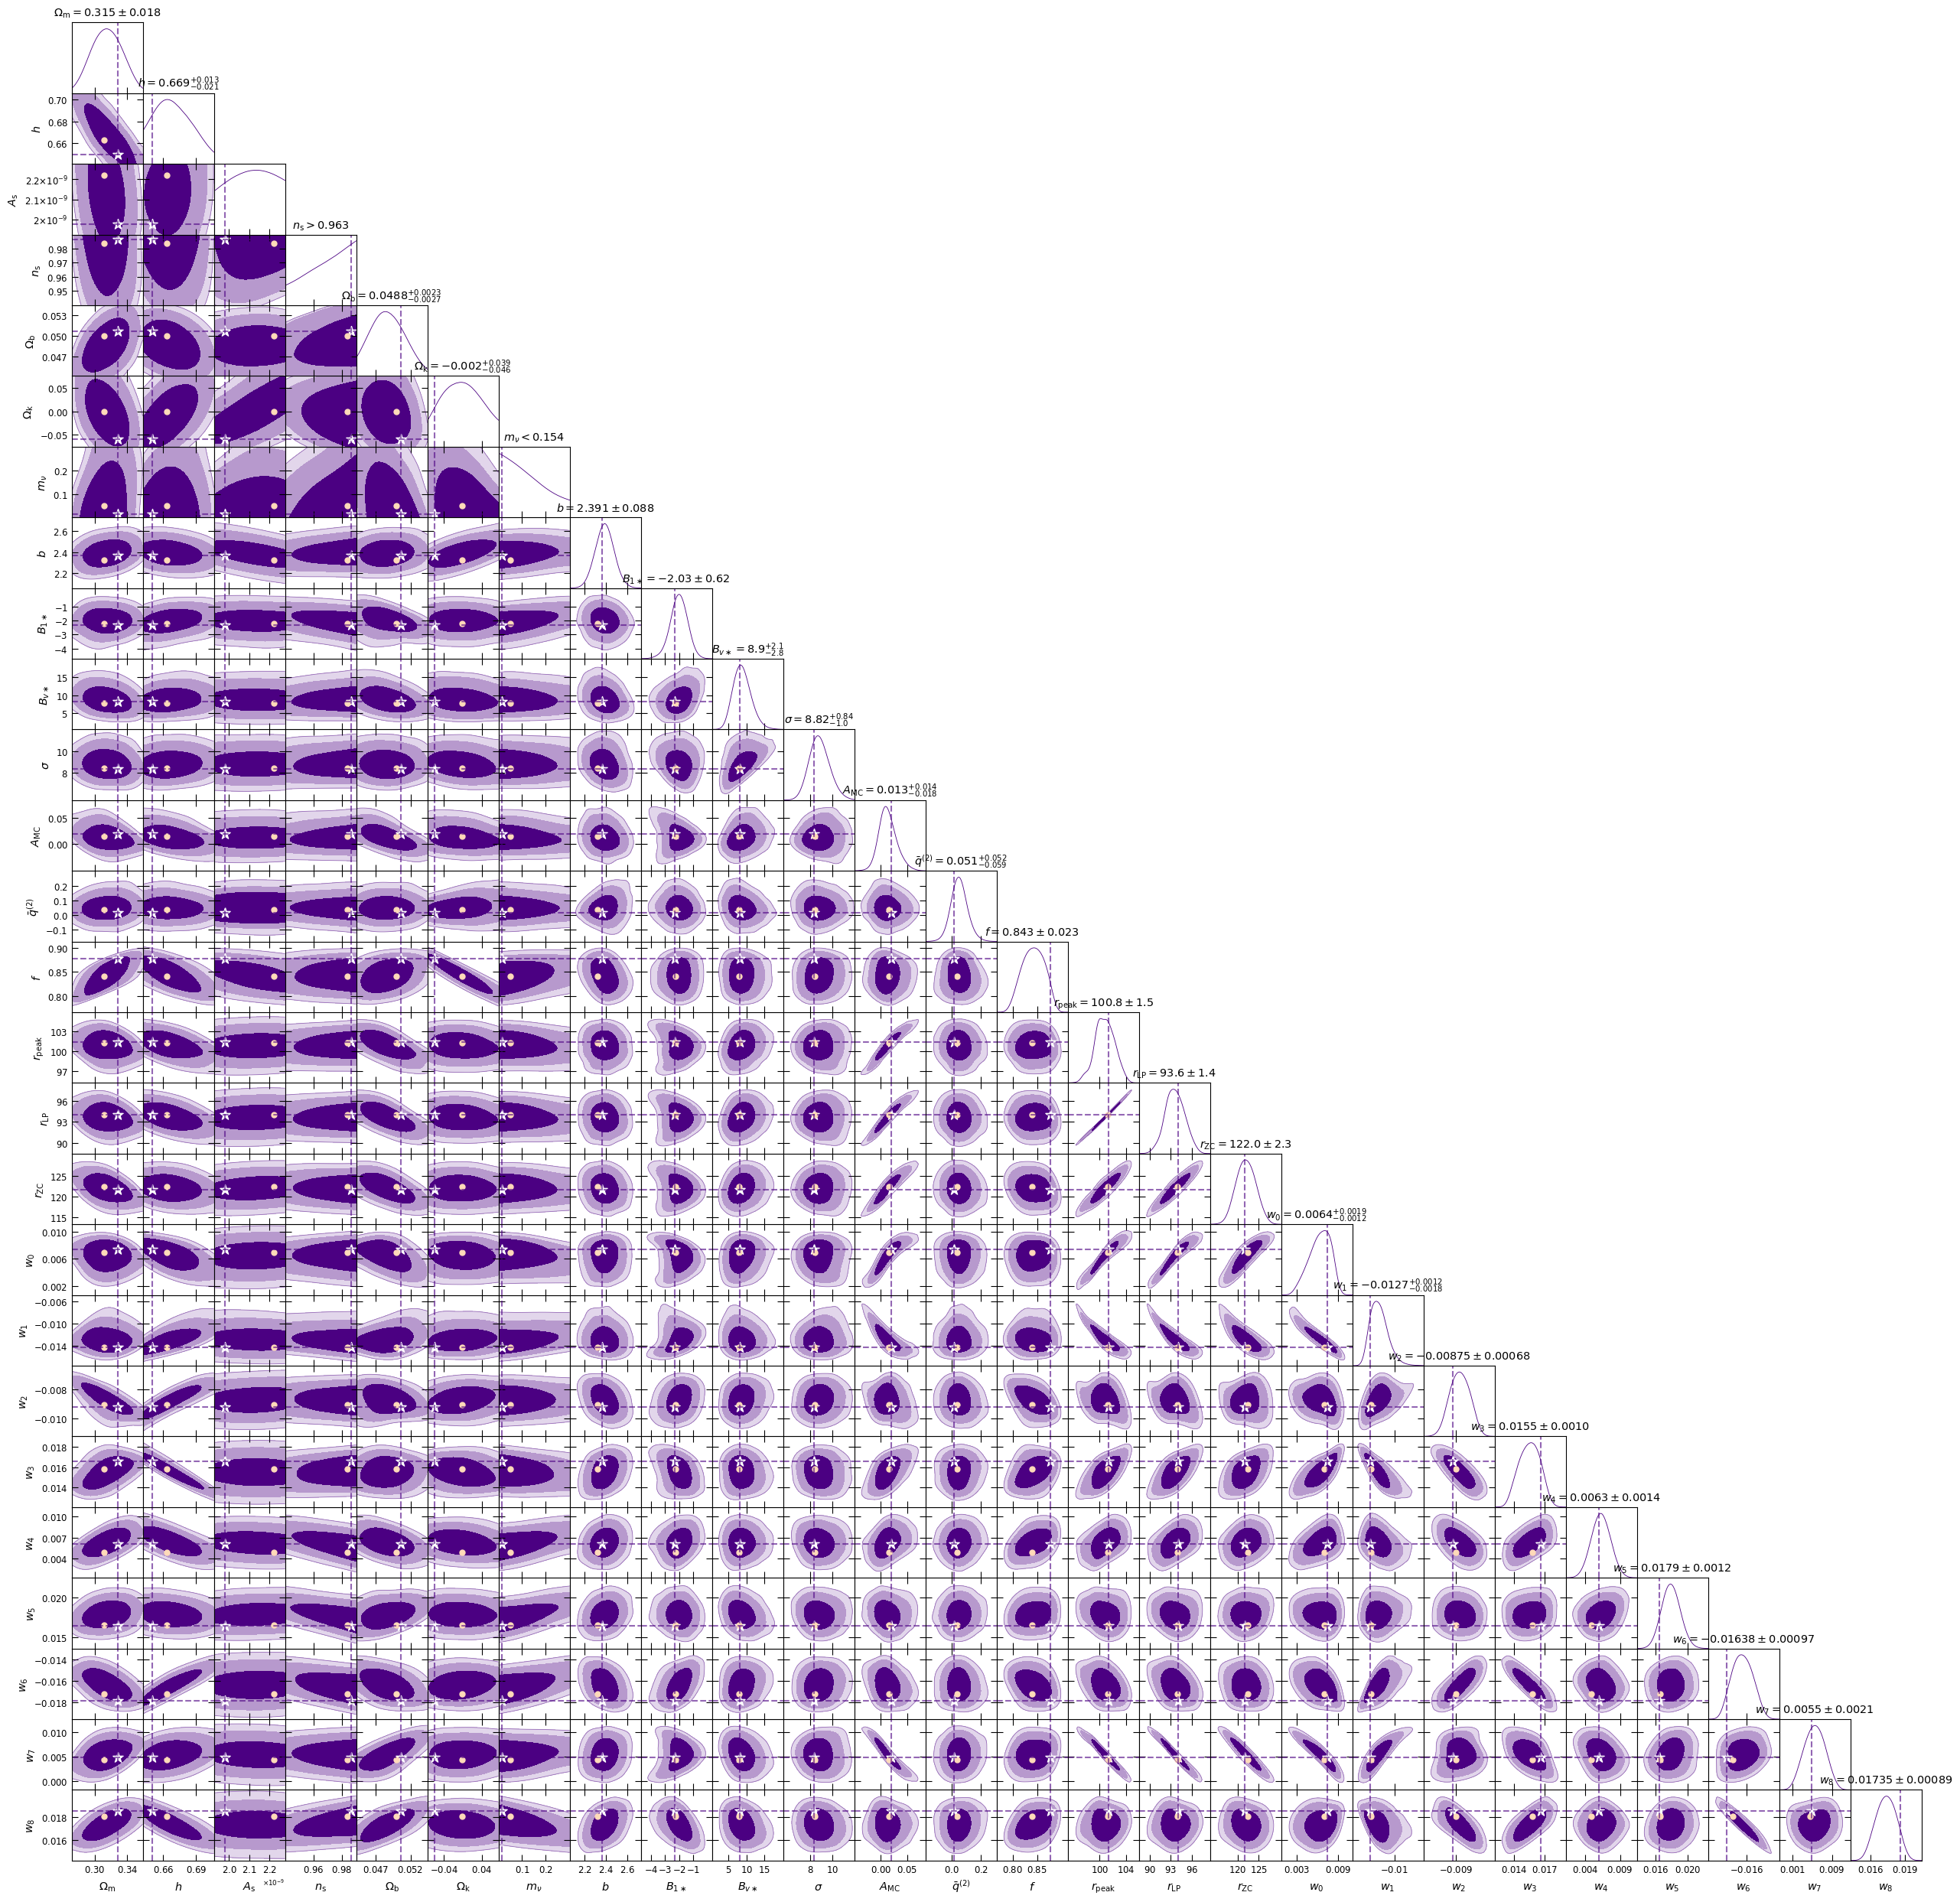

In [10]:
params_list = ssamp.all_sampled_params + ssamp.derived_list
marker_MAP = mcmc_MAP.copy()
marker_best = mcmc_best.copy()

plot_setup = {'save_fig':Save_Fig,'out_file':'contours_all.pdf',
              'marker_MAP':marker_MAP,'marker_best':marker_best}

ssamp.corner_plot(params_list,gd_sample,setup=plot_setup)

#### Cosmological

Writing to file: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/contours_cosmo.pdf


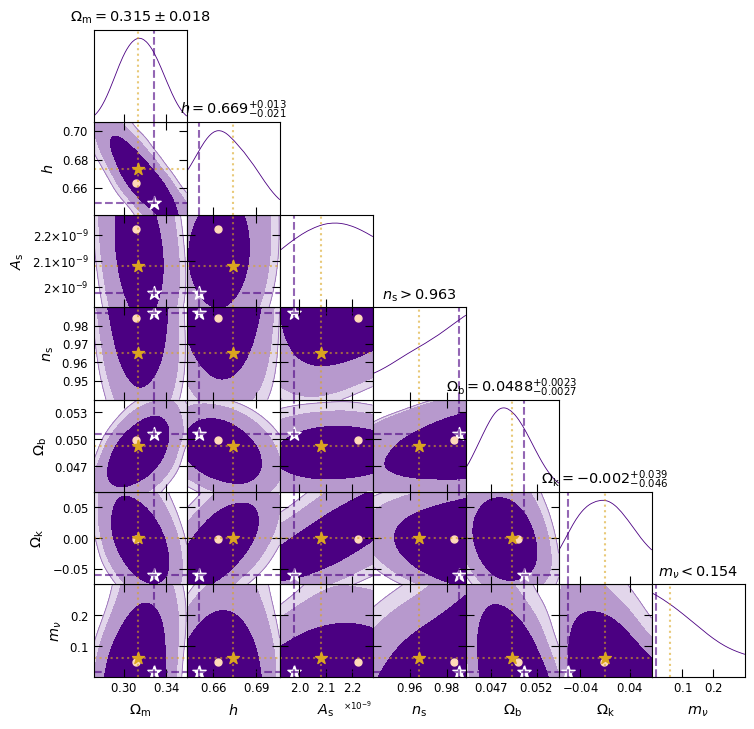

In [11]:
params_list = ssamp.agem.keys_vary
ind_list = ssamp.find_indices(params_list)
marker_MAP = mcmc_MAP[ind_list]
marker_best = mcmc_best[ind_list]
marker_truth = [GT_Dict[key] for key in params_list]

plot_setup = {'save_fig':Save_Fig,'out_file':'contours_cosmo.pdf',
              'marker_MAP':marker_MAP,'marker_best':marker_best,'marker_truth':marker_truth}

ssamp.corner_plot(params_list,gd_sample,setup=plot_setup)

#### SDBMC

Writing to file: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/contours_sdbmc.pdf


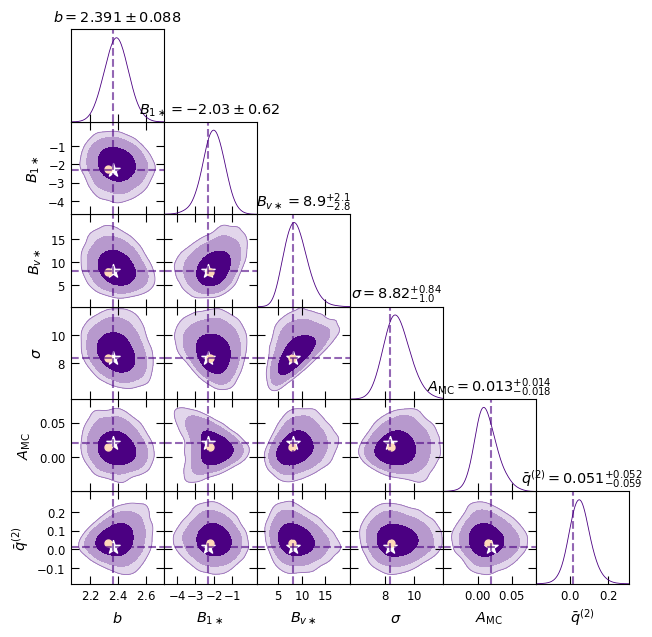

In [12]:
params_list = ssamp.all_sampled_params[len(ssamp.agem.keys_vary):]
ind_list = ssamp.find_indices(params_list)
marker_MAP = mcmc_MAP[ind_list]
marker_best = mcmc_best[ind_list]

plot_setup = {'save_fig':Save_Fig,'out_file':'contours_sdbmc.pdf',
              'marker_MAP':marker_MAP,'marker_best':marker_best}

ssamp.corner_plot(params_list,gd_sample,setup=plot_setup)

#### Derived

Writing to file: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/contours_derived.pdf


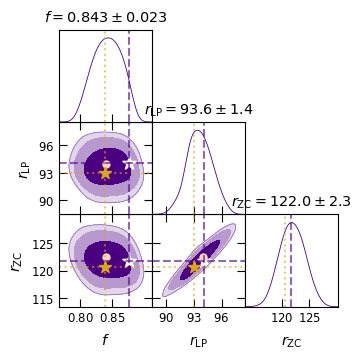

In [13]:
params_list = ['f','LP','ZC']
ind_list = ssamp.find_indices(params_list)
marker_MAP = mcmc_MAP[ind_list]
marker_best = mcmc_best[ind_list]
marker_truth = [GT_Dict[key][ssamp.sample] for key in params_list]

plot_setup = {'save_fig':Save_Fig,'out_file':'contours_derived.pdf',
              'marker_MAP':marker_MAP,'marker_best':marker_best,'marker_truth':marker_truth}

ssamp.corner_plot(params_list,gd_sample,setup=plot_setup)

#### Basis coefficients

Writing to file: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/contours_basis.pdf


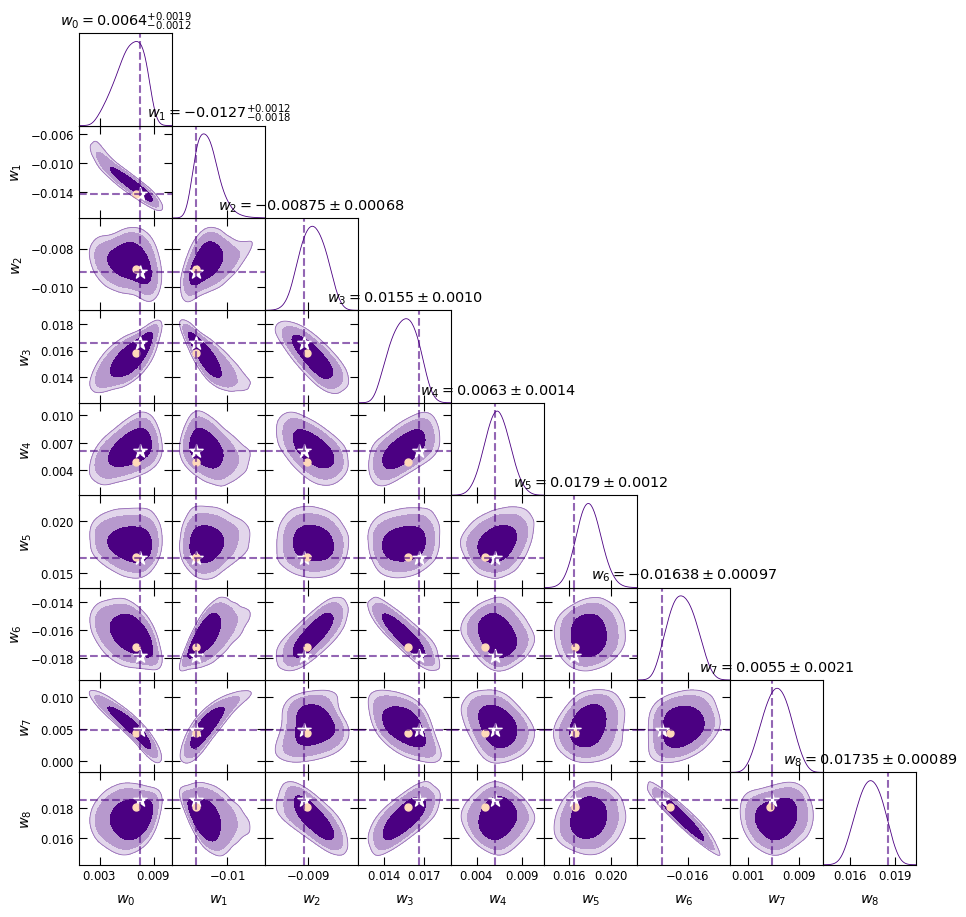

In [14]:
params_list = ssamp.agem.keys_agnostic[:ssamp.agem.n_basis]
ind_list = ssamp.find_indices(params_list)
marker_MAP = mcmc_MAP[ind_list]
marker_best = mcmc_best[ind_list]

plot_setup = {'save_fig':Save_Fig,'out_file':'contours_basis.pdf',
              'marker_MAP':marker_MAP,'marker_best':marker_best}

ssamp.corner_plot(params_list,gd_sample,setup=plot_setup)

### Best fit

[model] *WARNING* Ignored blocks/options: ['sampler', 'output', 'force', 'resume']
Setting up 20,6 layer feed-forward bi-neural network
... ... expecting data dim = 1, theta dim = 2, output dim = 1
... ... NNa using hidden layers of sizes [8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8]
... ... ... and activations [relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,relu,tanh,tanh,tanh,tanh,tanh]
... ... NNw using hidden layers of sizes [3,3,3,3,3,9]
... ... ... and activations [tanh,tanh,tanh,tanh,tanh,tanh]
... ... using loss function 'square'
... ... not using any regularization
... ... not using any weight decay in NNa
... ... not using any weight decay in NNw
Extracting basis functions as NN...
... extracting basis functions from NNa
... setting up 20 layer feed-forward neural network
Warning!: last activation tanh seems inconsistent with square loss. Proceed with caution!
... ... expecting data dim = 1, target dim = 8
... ... using hidden layers of sizes [8,8,8,8,8,8,8

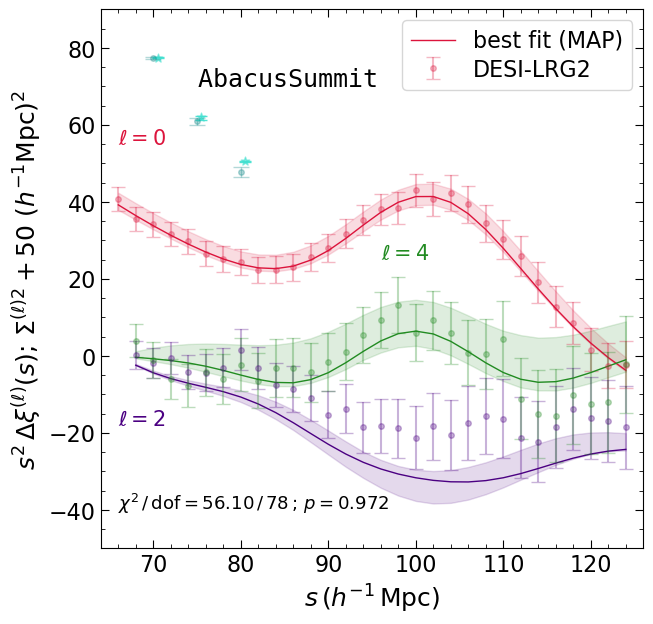

Writing to file: ./plots/AbacusSummit/base_c000/DESI-LRG2/nucdm/withAP/withEmuErr/LMax3_lgMmin12.90_z0.800/linear_recon.pdf


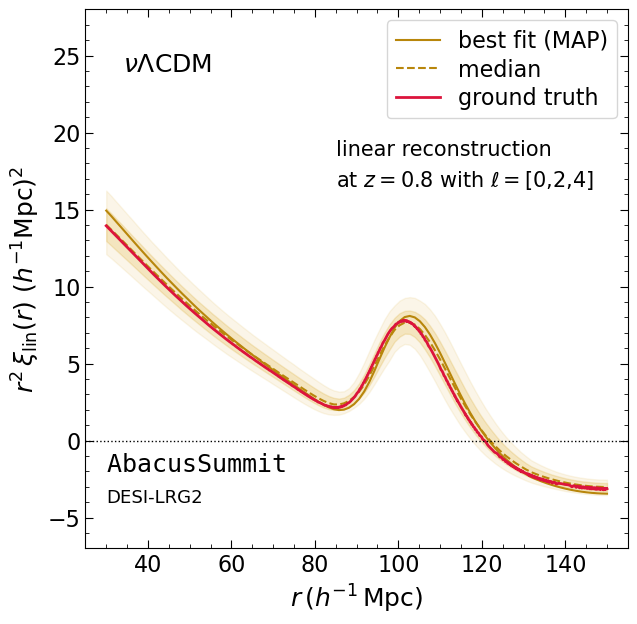

0 min 37.58 seconds



In [15]:
plot_setup = {'save_fig':Save_Fig,'show_gt':True,
              'out_file_bf':'best_fit.pdf','out_file_lin':'linear_recon.pdf'}

ssamp.show_bestfit(gd_sample,setup=plot_setup)